In [ ]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pandas import set_option
set_option("display.max_rows", 10)
pd.options.mode.chained_assignment = None

In [ ]:
df = pd.read_csv("/content/Well_1_final_new1.csv")
df.head()

,DEPT[M],WELL,CALIPER[MM],DEN[GM/CC],RES(64N),RES[OHM],SP[MV],GAM[API],LITHOLOGY DESCRIPTION,Formation,Classified
0,24.00,1,12.6696,2.59367,4.50623,21.0600,64.5311,77.5320,"Fine graineded SST, brown",Raniganj,Sandstone (SST)
1,24.89,1,12.6886,2.30613,3.39083,22.2852,56.2742,79.1260,"Fine graineded SST, brown",Raniganj,Sandstone (SST)
2,25.19,1,12.6710,2.37167,3.29750,21.9935,56.3978,78.5932,Carb shale,Raniganj,Carb Shale
3,25.64,1,12.6645,2.32154,3.11173,22.5185,48.2233,74.8741,Grey Shale,Raniganj,Grey Shale
4,25.95,1,12.6589,1.97248,4.36571,22.5186,32.1008,109.9220,Siltstone,Raniganj,Siltstone


In [ ]:
# Create a cross-tabulation of Formation vs Classified
distribution = pd.crosstab(df['Formation'], df['Classified'])

# Display the result
print(distribution)

Classified       Carb Shale  Grey Shale  Sandstone (SST)  Siltstone  alt  \
Formation                                                                  
Barakar                   0           0               37          0    0   
Barren Measures           0           1                0          0    0   
Raniganj                 12          57              137          4    9   

Classified       coal  dgs  ss  
Formation                       
Barakar             1    0  16  
Barren Measures     0  158   3  
Raniganj           46   17  64  


In [ ]:
# 2. Clean target and filter unwanted classes
df = df.dropna(subset=['Classified'])
df['Classified'] = df['Classified'].replace({'Carb shale': 'Carb Shale', 'gs': 'Grey Shale'})
classes_to_remove = ['m', 'Shale', 'Top Soil', 'Siltstone',  'alt']
df = df[~df['Classified'].isin(classes_to_remove)]

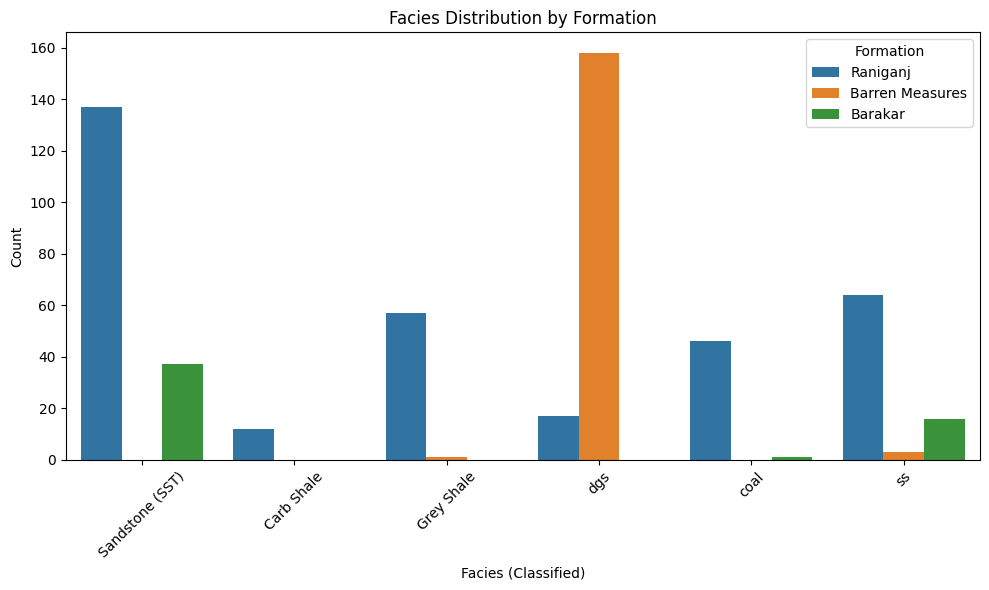

In [ ]:
# Plotting count of each facies (classified lithology) for every formation
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Classified', hue='Formation')
plt.xlabel('Facies (Classified)')
plt.ylabel('Count')
plt.title('Facies Distribution by Formation')
plt.xticks(rotation=45)
plt.legend(title='Formation')
plt.tight_layout()
plt.show()

In [ ]:
df2 = pd.read_csv("/content/Well_2_final_new1.csv")
df2.head()

,DEPT[M],WELL,CALIPER[MM],DEN[GM/CC],RES(64N),RES[OHM],SP[MV],GAM[API],LITHOLOGY DESCRIPTION,Formation,Classified
0,24.0,2,10.3561,1.83074,59.34370,31.6238,81.7457,94.5149,"Very fine grained Sandstone , loose",Raniganj,Sandstone (SST)
1,25.5,2,10.3689,2.34565,55.14370,32.7835,98.9245,73.0805,"Very fine grained Sandstone , ferruginous",Raniganj,Sandstone (SST)
2,27.0,2,10.3799,2.31701,48.15920,29.1288,73.0515,81.3777,Claystone,Raniganj,Sandstone (SST)
3,28.5,2,10.3408,2.08735,7.41352,27.5045,62.4829,104.1950,Claystone,Raniganj,Sandstone (SST)
4,31.0,2,13.6928,1.73802,-2.56270,62.8995,40.3063,158.1270,Very fine grained Sandstone mixed with clay an...,Raniganj,Sandstone (SST)


In [ ]:
# prompt: unique values in df['Classified']

df2['Classified'].unique()

array(['Sandstone (SST)', 'dgs', 'Grey Shale', 'coal', 'Carb shale', 'ss',
       'alt', 'Shale'], dtype=object)

In [ ]:
classes_to_remove = ['m', 'Shale', 'Top Soil', 'Siltstone', 'alt']
df2 = df2[~df2['Classified'].isin(classes_to_remove)]

In [ ]:
df2['Classified'].unique()

array(['Sandstone (SST)', 'dgs', 'Grey Shale', 'coal', 'Carb shale', 'ss'],
      dtype=object)

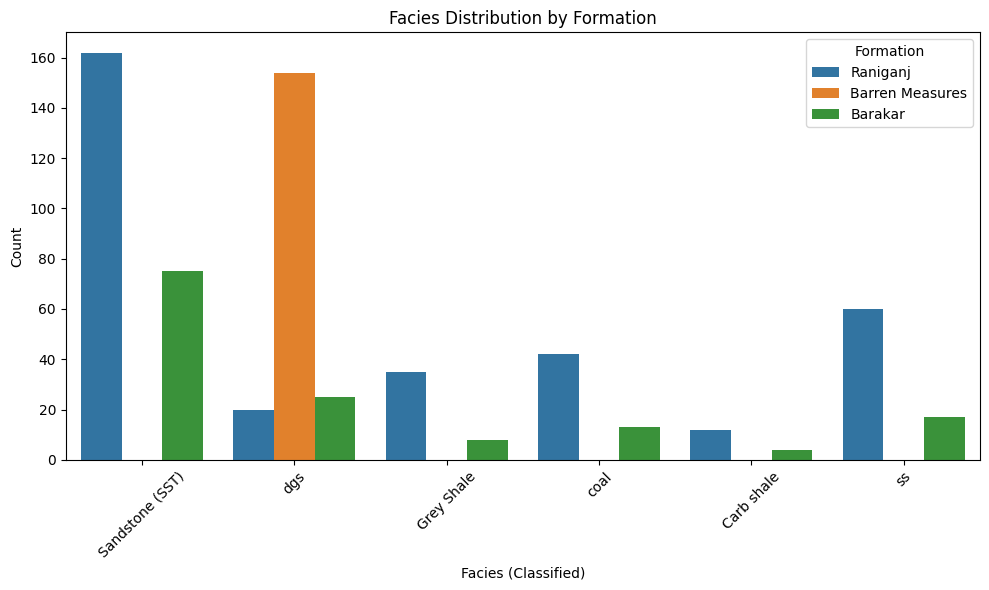

In [ ]:
# Plotting count of each facies (classified lithology) for every formation
plt.figure(figsize=(10, 6))
sns.countplot(data=df2, x='Classified', hue='Formation')
plt.xlabel('Facies (Classified)')
plt.ylabel('Count')
plt.title('Facies Distribution by Formation')
plt.xticks(rotation=45)
plt.legend(title='Formation')
plt.tight_layout()
plt.show()

In [ ]:
df3 = pd.read_csv("/content/Well_3_final_new1.csv")
df3.head()

,DEPT[M],WELL,CALIPER[MM],DEN[GM/CC],GAM[API],RES(64N),RES[OHM],SP[MV],LITHOLOGY DESCRIPTION,Formation,Classified
0,29.21,3,10.24000,1.95984,246.295,126.153,141.905,-119.251,CARB SHALE,Raniganj,Carb Shale
1,29.68,3,10.75500,1.87499,268.980,111.552,102.998,-121.101,SHALE,Raniganj,Grey Shale
2,30.39,3,10.12000,2.63000,199.510,129.247,132.549,-112.550,SANDSTONE,Raniganj,Sandstone (SST)
3,32.00,3,10.00000,2.56997,117.152,200.749,173.149,-122.301,SANDSTONE,Raniganj,Sandstone (SST)
4,35.00,3,9.88502,2.56997,90.286,221.745,176.800,-116.200,SANDSTONE,Raniganj,Sandstone (SST)


In [ ]:
df3['Classified'].unique()

array(['Carb Shale', 'Grey Shale', 'Sandstone (SST)', 'coal', 'ss',
       'Shale', 'dgs', 'alt'], dtype=object)

In [ ]:
classes_to_remove = ['m', 'Shale', 'Top Soil', 'Siltstone', 'alt']
df3 = df3[~df3['Classified'].isin(classes_to_remove)]

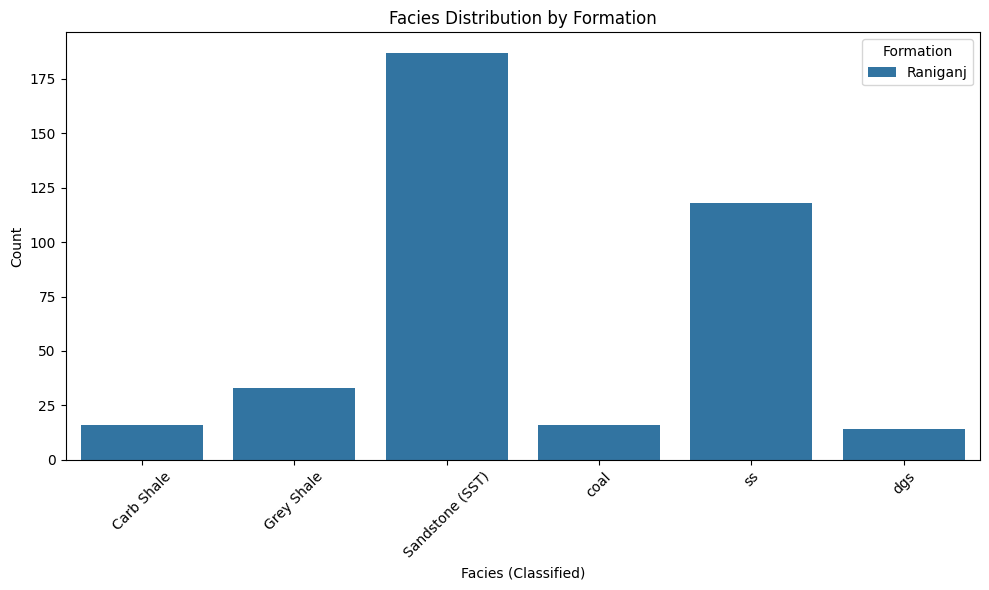

In [ ]:
# Plotting count of each facies (classified lithology) for every formation
plt.figure(figsize=(10, 6))
sns.countplot(data=df3, x='Classified', hue='Formation')
plt.xlabel('Facies (Classified)')
plt.ylabel('Count')
plt.title('Facies Distribution by Formation')
plt.xticks(rotation=45)
plt.legend(title='Formation')
plt.tight_layout()
plt.show()

In [ ]:
df.shape

(39270, 12)

In [ ]:
# prompt: Now I have to change columns name as 'CALIPER[' as 'CALIPER[MM]', 'DEN(CDL)' as 'DEN[GM/CC]', 'SANG[DEG' as 'SANG[DEG]', 'GAM(NAT)' as 'GAM[API]'

df = df.rename(columns={'CALIPER[': 'CALIPER[MM]', 'DEN(CDL)': 'DEN[GM/CC]', 'SANG[DEG': 'SANG[DEG]', 'GAM(NAT)': 'GAM[API]'})
df.head()

,DEPT[M],CALIPER[MM],DEN[GM/CC],RES(16N),RES(64N),RES[OHM],SANG[DEG],SP[MM],GAM[API],LITHOLOGY DESCRIPTION,Formation,Classified
0,0.52,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.18623,NaN,NaN,NaN
1,0.54,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.49196,NaN,NaN,NaN
2,0.56,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.80240,NaN,NaN,NaN
3,0.58,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.11270,NaN,NaN,NaN
4,0.60,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.42310,NaN,NaN,NaN


In [ ]:
df.isnull().sum()

,0
DEPT[M],0
CALIPER[MM],145
DEN[GM/CC],145
RES(16N),145
RES(64N),145
...,...
SP[MM],145
GAM[API],145
LITHOLOGY DESCRIPTION,124
Formation,124


In [ ]:
df.dropna(inplace=True)
df.isna().sum()

,0
DEPT[M],0
CALIPER[MM],0
DEN[GM/CC],0
RES(16N),0
RES(64N),0
...,...
SP[MM],0
GAM[API],0
LITHOLOGY DESCRIPTION,0
Formation,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [ ]:
df.head()

,DEPT[M],CALIPER[MM],DEN[GM/CC],RES(16N),RES(64N),RES[OHM],SANG[DEG],SP[MM],GAM[API],LITHOLOGY DESCRIPTION,Formation,Classified
124,3.00,12.6650,2.14521,2855.94,2892.47,3527.19,0.28967,-169.379,104.613,"Top Soil, Fine graineded, Brown",Soil,Top Soil
125,3.02,12.6650,2.14521,2855.94,2892.47,3527.25,0.28967,-169.379,104.084,"Top Soil, Fine graineded, Brown",Soil,Top Soil
126,3.04,12.6631,2.10521,2855.89,2892.47,3527.25,0.28967,-169.379,103.553,"Top Soil, Fine graineded, Brown",Soil,Top Soil
127,3.06,12.6631,2.10518,2855.89,2892.47,3527.19,0.28967,-169.379,104.614,"Top Soil, Fine graineded, Brown",Soil,Top Soil
128,3.08,12.6649,2.16334,2855.89,2380.50,3527.19,0.28967,-169.379,105.676,"Top Soil, Fine graineded, Brown",Soil,Top Soil


In [ ]:
columns_to_drop = ['RES(16N)', 'LITHOLOGY DESCRIPTION', 'Formation']
df.drop(columns=columns_to_drop, inplace=True)

df.head()

,DEPT[M],CALIPER[MM],DEN[GM/CC],RES(64N),RES[OHM],SANG[DEG],SP[MM],GAM[API],Classified
124,3.00,12.6650,2.14521,2892.47,3527.19,0.28967,-169.379,104.613,Top Soil
125,3.02,12.6650,2.14521,2892.47,3527.25,0.28967,-169.379,104.084,Top Soil
126,3.04,12.6631,2.10521,2892.47,3527.25,0.28967,-169.379,103.553,Top Soil
127,3.06,12.6631,2.10518,2892.47,3527.19,0.28967,-169.379,104.614,Top Soil
128,3.08,12.6649,2.16334,2380.50,3527.19,0.28967,-169.379,105.676,Top Soil


In [ ]:
df.describe()

,DEPT[M],CALIPER[MM],DEN[GM/CC],RES(64N),RES[OHM],SANG[DEG],SP[MM],GAM[API]
count,39001.000000,39001.000000,39001.000000,39001.000000,39001.000000,39001.000000,39001.000000,39001.000000
mean,393.000000,10.844720,2.361399,92.127176,101.377085,1.379691,-86.211177,185.589019
std,225.175265,2.582899,0.212191,2324.254354,291.838288,0.563087,89.464070,69.709756
min,3.000000,7.207950,0.834818,-13.793800,17.209800,0.073301,-365.463000,27.614400
25%,198.000000,8.106380,2.319810,10.124800,29.927400,0.935156,-153.277000,124.795000
50%,393.000000,10.186600,2.389180,16.487500,57.288100,1.245320,-104.971000,193.518000
75%,588.000000,12.576300,2.461530,33.114300,95.149600,1.595740,21.023300,245.871000
max,783.000000,18.745100,3.159010,100000.000000,3527.250000,3.347220,75.444100,357.212000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39001 entries, 124 to 39269
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DEPT[M]      39001 non-null  float64
 1   CALIPER[MM]  39001 non-null  float64
 2   DEN[GM/CC]   39001 non-null  float64
 3   RES(64N)     39001 non-null  float64
 4   RES[OHM]     39001 non-null  float64
 5   SANG[DEG]    39001 non-null  float64
 6   SP[MM]       39001 non-null  float64
 7   GAM[API]     39001 non-null  float64
 8   Classified   39001 non-null  object 
dtypes: float64(8), object(1)
memory usage: 3.0+ MB


In [ ]:
# prompt: show all the unique values of column 'Classified'
print(df['Classified'].unique())

['Top Soil' 'Sandstone (SST)' 'Siltstone' 'Carb Shale' 'Grey Shale' 'dgs'
 'coal' 'ss' 'alt' 'm']


In [ ]:
df['Classified'].unique()

array(['Top Soil', 'Sandstone (SST)', 'Siltstone', 'Carb Shale',
       'Grey Shale', 'dgs', 'coal', 'ss', 'alt', 'm'], dtype=object)

In [ ]:
# prompt: now make a dict in which assign each unique value of column 'Classified' as 1, 2....10... for ex like   'Top Soil' as 1, ''Sandstone (SST)'' as 2....and so on

unique_classes = df['Classified'].unique()
class_mapping = {class_name: i + 1 for i, class_name in enumerate(unique_classes)}

class_mapping
# Apply the mapping to create a new column or modify the existing one
# df['Classified_Encoded'] = df['Classified'].map(class_mapping)
# print(df.head())

{'Top Soil': 1,
 'Sandstone (SST)': 2,
 'Siltstone': 3,
 'Carb Shale': 4,
 'Grey Shale': 5,
 'dgs': 6,
 'coal': 7,
 'ss': 8,
 'alt': 9,
 'm': 10}

In [ ]:
df['Facies'] = df['Classified'].map(class_mapping)
print(df.tail())

       DEPT[M]  CALIPER[MM]  DEN[GM/CC]  RES(64N)  RES[OHM]  SANG[DEG]  \
39265   782.92      7.49650     2.60293   80.6262   156.288    2.64201   
39266   782.94      7.49650     2.57983   80.7191   154.305    2.64201   
39267   782.96      7.47899     2.55305   80.7191   153.374    3.12119   
39268   782.98      7.48082     2.56708   80.6727   154.596    2.32726   
39269   783.00      7.48082     2.66173   80.6727   154.596    2.32726   

        SP[MM]  GAM[API] Classified  Facies  
39265 -83.5362   132.875          m      10  
39266 -83.5362   132.875          m      10  
39267 -83.5362   133.771          m      10  
39268 -83.5362   132.426          m      10  
39269 -83.5362   131.078          m      10  


In [ ]:
df['Classified'].unique()

array(['Top Soil', 'Sandstone (SST)', 'Siltstone', 'Carb Shale',
       'Grey Shale', 'dgs', 'coal', 'ss', 'alt', 'm'], dtype=object)

In [ ]:
# Step 1: Define new facies labels and assign colors
facies_labels = ['Top Soil', 'Sandstone (SST)', 'Siltstone', 'Carb Shale',
                 'Grey Shale', 'dgs', 'coal', 'ss', 'alt', 'm']

# Assign a unique color to each label (10 labels = 10 colors)
facies_colors = ['#F4D03F', '#F5B041', '#DC7633', '#6E2C00',
                 '#1B4F72', '#2E86C1', '#AED6F1', '#A569BD', '#196F3D', '#117864']

# Step 2: Create a dictionary mapping facies labels to colors
facies_color_map = {}
for ind, label in enumerate(facies_labels):
    facies_color_map[label] = facies_colors[ind]


In [ ]:
df = df.rename(columns={'Classified': 'FaciesLabels'})
print(df.head())

     DEPT[M]  CALIPER[MM]  DEN[GM/CC]  RES(64N)  RES[OHM]  SANG[DEG]   SP[MM]  \
124     3.00      12.6650     2.14521   2892.47   3527.19    0.28967 -169.379   
125     3.02      12.6650     2.14521   2892.47   3527.25    0.28967 -169.379   
126     3.04      12.6631     2.10521   2892.47   3527.25    0.28967 -169.379   
127     3.06      12.6631     2.10518   2892.47   3527.19    0.28967 -169.379   
128     3.08      12.6649     2.16334   2380.50   3527.19    0.28967 -169.379   

     GAM[API] FaciesLabels  Facies  
124   104.613     Top Soil       1  
125   104.084     Top Soil       1  
126   103.553     Top Soil       1  
127   104.614     Top Soil       1  
128   105.676     Top Soil       1  


In [ ]:
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
numeric_columns

Index(['DEPT[M]', 'CALIPER[MM]', 'DEN[GM/CC]', 'RES(64N)', 'RES[OHM]',
       'SANG[DEG]', 'SP[MM]', 'GAM[API]', 'Facies'],
      dtype='object')

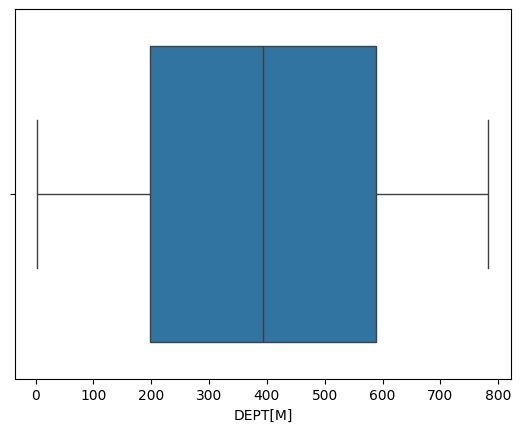

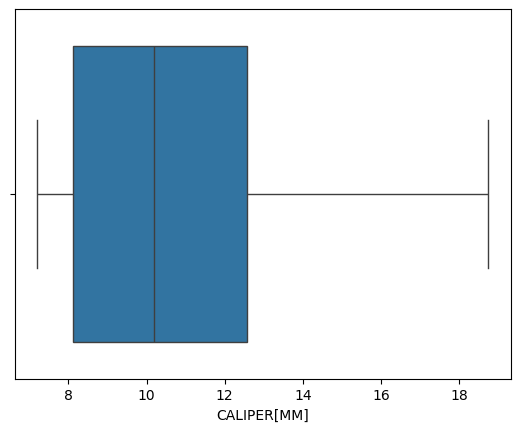

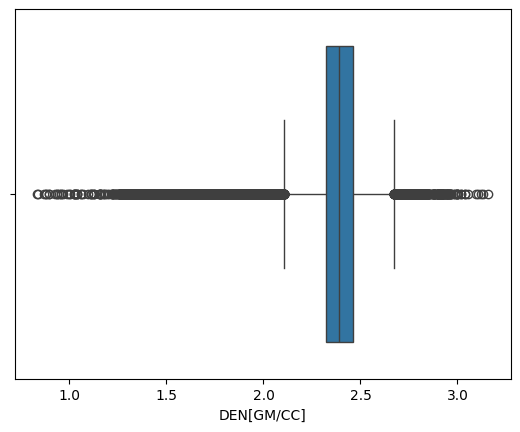

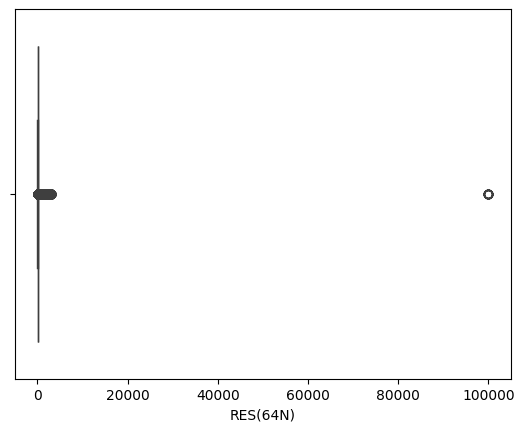

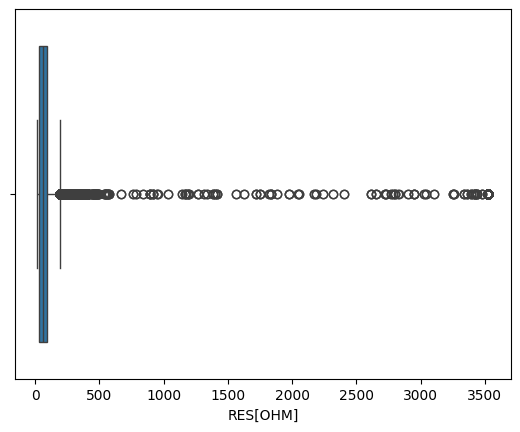

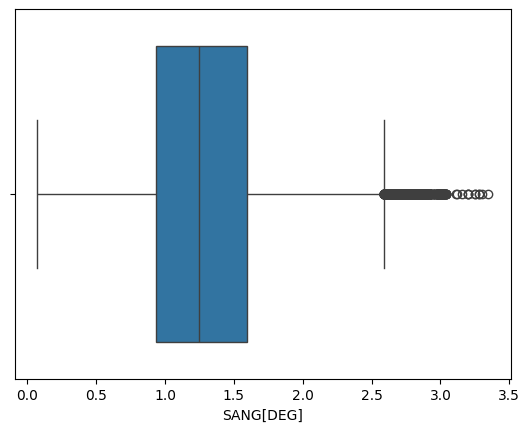

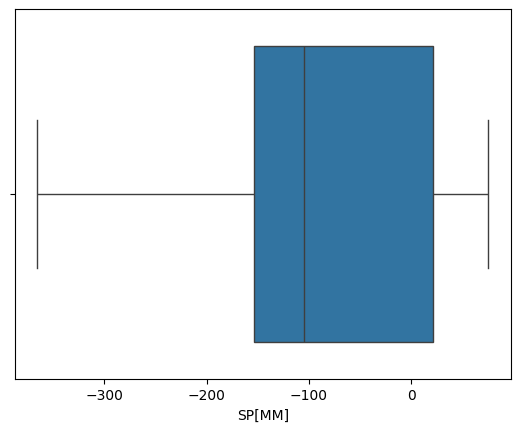

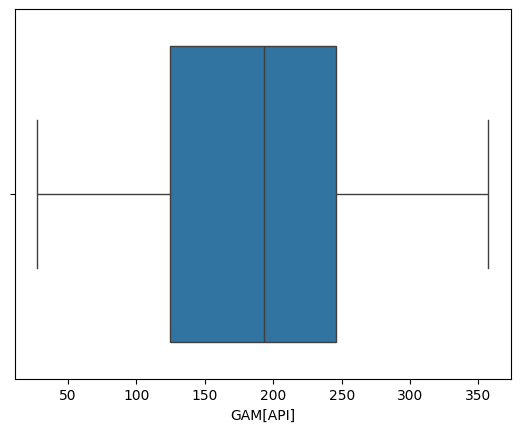

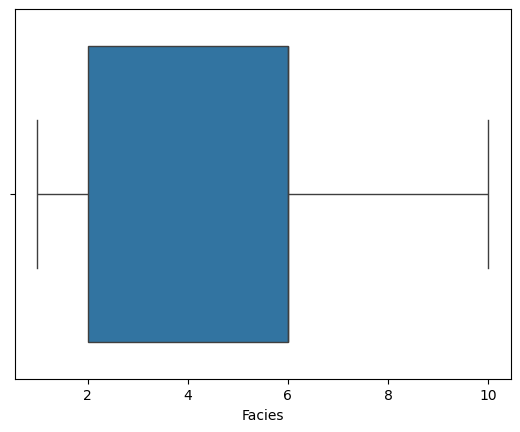

In [ ]:
for col in numeric_columns:
    sns.boxplot(x=df[col])
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

def make_facies_log_plot(df, facies_colors):
    # Sort by depth
    df = df.sort_values(by='DEPT[M]')

    # Create colormap
    cmap_facies = colors.ListedColormap(facies_colors[:len(facies_colors)], 'indexed')

    ztop = df['DEPT[M]'].min()
    zbot = df['DEPT[M]'].max()

    # Repeat facies values for imshow
    cluster = np.repeat(np.expand_dims(df['Facies'].values, axis=1), 100, axis=1)

    # Create subplot layout
    f, ax = plt.subplots(nrows=1, ncols=6, figsize=(8, 8))

    ax[0].plot(df['CALIPER[MM]'], df['DEPT[M]'], '-g')
    ax[1].plot(df['DEN[GM/CC]'], df['DEPT[M]'], '-', color='blue')
    ax[2].plot(df['RES(64N)'], df['DEPT[M]'], '-', color='orange')
    ax[3].plot(df['GAM[API]'], df['DEPT[M]'], '-', color='brown')
    ax[4].plot(df['SANG[DEG]'], df['DEPT[M]'], '-', color='black')

    # Facies image column
    im = ax[5].imshow(cluster, interpolation='none', aspect='auto',
                      cmap=cmap_facies, vmin=1, vmax=len(facies_colors))

    # Add colorbar
    divider = make_axes_locatable(ax[5])
    cax = divider.append_axes("right", size="20%", pad=0.05)
    cbar = plt.colorbar(im, cax=cax)
    cbar.set_label('Facies')

    # Format plot
    for i in range(len(ax)-1):
        ax[i].set_ylim(ztop, zbot)
        ax[i].invert_yaxis()
        ax[i].grid(True)
        ax[i].locator_params(axis='x', nbins=3)

    ax[0].set_xlabel("CALIPER")
    ax[1].set_xlabel("DENSITY")
    ax[2].set_xlabel("RES(64N)")
    ax[3].set_xlabel("GAM")
    ax[4].set_xlabel("SANG")
    ax[5].set_xlabel("Facies")

    # Hide y-tick labels for middle plots
    for i in range(1, 6):
        ax[i].set_yticklabels([])

    f.suptitle('Well Log Visualization', fontsize=14, y=0.94)
    plt.tight_layout()
    plt.show()


In [ ]:
# {'Top Soil': 1,
 'Sandstone (SST)': 2,
 'Siltstone': 3,
 'Carb Shale': 4,
 'Grey Shale': 5,
 'dgs': 6,
 'coal': 7,
 'ss': 8,
 'alt': 9,
 'm': 10}

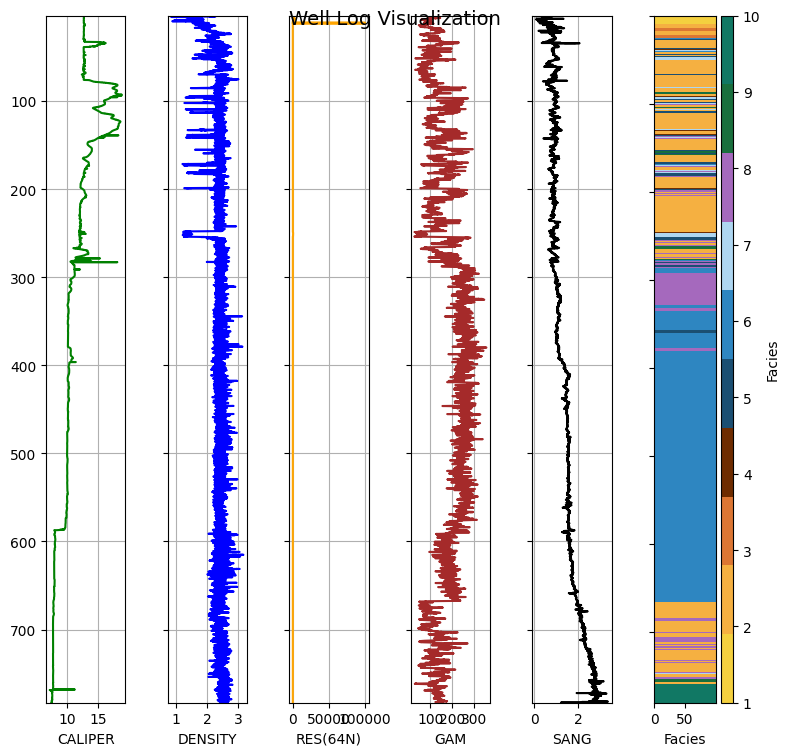

In [ ]:
make_facies_log_plot(df, facies_colors)

,count
Top Soil,515
Sandstone (SST),12407
Siltstone,282
Carb Shale,290
Grey Shale,1349
dgs,16965
coal,1173
ss,4375
alt,594
m,1051


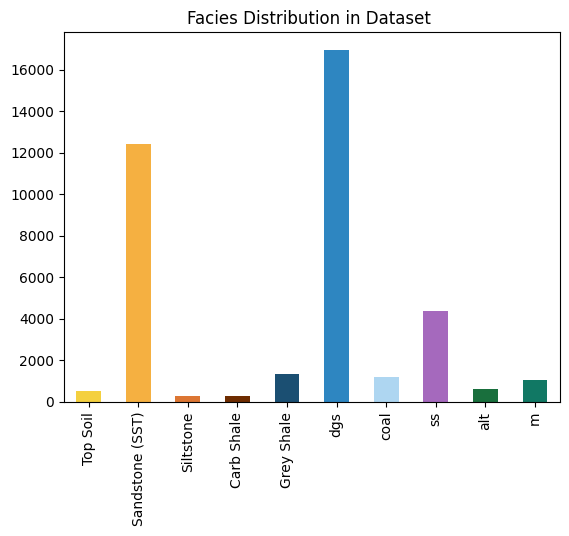

In [ ]:
#count the number of unique entries for each facies, sort them by
#facies number (instead of by number of entries)
facies_counts = df['Facies'].value_counts().sort_index()
#use facies labels to index each count
facies_counts.index = facies_labels

facies_counts.plot(kind='bar',color=facies_colors,
                   title='Facies Distribution in Dataset ')
facies_counts
#plt.savefig("F_Dist.png", dpi=300)

In [ ]:
df.columns

Index(['DEPT[M]', 'CALIPER[MM]', 'DEN[GM/CC]', 'RES(64N)', 'RES[OHM]',
       'SANG[DEG]', 'SP[MM]', 'GAM[API]', 'FaciesLabels', 'Facies'],
      dtype='object')

In [ ]:
df.head()

,DEPT[M],CALIPER[MM],DEN[GM/CC],RES(64N),RES[OHM],SANG[DEG],SP[MM],GAM[API],FaciesLabels,Facies
124,3.00,12.6650,2.14521,2892.47,3527.19,0.28967,-169.379,104.613,Top Soil,1
125,3.02,12.6650,2.14521,2892.47,3527.25,0.28967,-169.379,104.084,Top Soil,1
126,3.04,12.6631,2.10521,2892.47,3527.25,0.28967,-169.379,103.553,Top Soil,1
127,3.06,12.6631,2.10518,2892.47,3527.19,0.28967,-169.379,104.614,Top Soil,1
128,3.08,12.6649,2.16334,2380.50,3527.19,0.28967,-169.379,105.676,Top Soil,1


In [ ]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Now compute correlation
correlation_matrix = numeric_df.corr()
print(correlation_matrix)


              DEPT[M]  CALIPER[MM]  DEN[GM/CC]  RES(64N)  RES[OHM]  SANG[DEG]  \
DEPT[M]      1.000000    -0.878073    0.288619 -0.044148 -0.097590   0.906078   
CALIPER[MM] -0.878073     1.000000   -0.227760  0.017795  0.033531  -0.756182   
DEN[GM/CC]   0.288619    -0.227760    1.000000 -0.078160 -0.327441   0.259457   
RES(64N)    -0.044148     0.017795   -0.078160  1.000000  0.116677  -0.036371   
RES[OHM]    -0.097590     0.033531   -0.327441  0.116677  1.000000  -0.064384   
SANG[DEG]    0.906078    -0.756182    0.259457 -0.036371 -0.064384   1.000000   
SP[MM]      -0.449852     0.537470   -0.189716 -0.037395  0.007614  -0.228793   
GAM[API]     0.163590    -0.160743    0.216837 -0.045110 -0.243194  -0.051620   
Facies       0.350009    -0.342878    0.120192 -0.047624 -0.195766   0.247222   

               SP[MM]  GAM[API]    Facies  
DEPT[M]     -0.449852  0.163590  0.350009  
CALIPER[MM]  0.537470 -0.160743 -0.342878  
DEN[GM/CC]  -0.189716  0.216837  0.120192  
RES(64N)    -

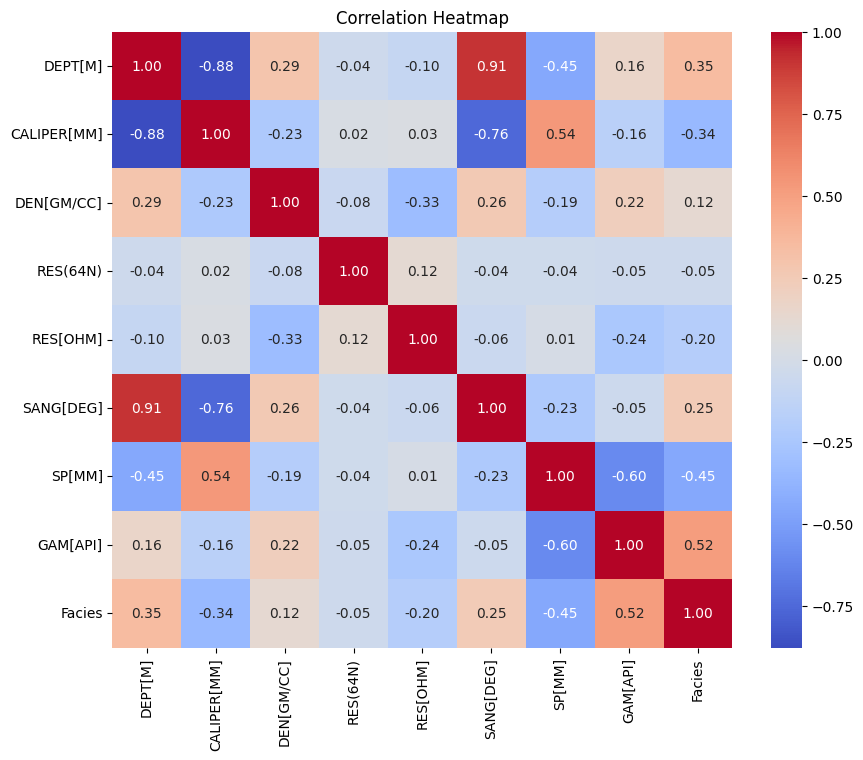

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
df['RES(64N)'].describe()

,RES(64N)
count,39001.000000
mean,92.127176
std,2324.254354
min,-13.793800
25%,10.124800
50%,16.487500
75%,33.114300
max,100000.000000


In [ ]:
# plot the frequency for RES(64N)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.histplot(df['RES(64N)'], kde=True)
plt.title('Frequency Distribution of RES(64N)')
plt.xlabel('RES(64N)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [ ]:
X = df.drop(['DEPT[M]', 'Formation', 'Facies','FaciesLabels'], axis=1)
y = df['Facies'].values

In [ ]:
from sklearn.preprocessing import StandardScaler
cols_to_scale = ['CALIPER[MM]', 'DEN[GM/CC]', 'RES(64N)', 'RES[OHM]',
       'SANG[DEG]', 'SP[MM]', 'GAM[API]']
scaler = StandardScaler()
X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    return vif_df


In [ ]:
calculate_vif(X)

In [ ]:
calculate_vif(X.drop('DEN[GM/CC]', axis = 'columns'))

In [ ]:
X_reduced = X.drop('DEN[GM/CC]', axis = 'columns')

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
        scaled_features, y, test_size=0.2, random_state=10)